# Histogram Plot Gallery

Histogram plots show the distribution of a numerical metric by binning values and counting how many fall in each bin. They're the right pick when the question is about *shape* (where the mass sits, how skewed it is, whether there's more than one mode) rather than about an individual value.

Histogram plots excel at:
- **Spread and shape**: see whether basket sizes are tightly grouped or long-tailed
- **Multi-modal patterns**: surface separate behaviours that average out in summary stats
- **Segment comparison**: overlay distributions per customer tier or channel
- **Outlier focus**: clip or drop extremes to see the central mass clearly

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from openretailscience.plots import histogram

In [ ]:
# Hand-crafted retail datasets shared across the gallery examples. Each one is
# drawn from continuous distributions so the histograms render smoothly instead
# of leaving gaps between sparse discrete values.

rng = np.random.default_rng(42)

# Basket amounts ($) for one week of transactions. Bimodal: a low "top-up" mode
# around $30 and a higher "weekly shop" mode around $100, with a thin upper tail
# of large baskets out past $150 (the clip_range demo pulls these into view).
_top_ups = rng.normal(30, 6, 220).clip(min=5)
_weekly_shops = rng.normal(100, 12, 300).clip(min=40)
_long_tail = rng.normal(160, 20, 40).clip(min=100)
basket_data = pd.DataFrame({"basket_amount": np.concatenate([_top_ups, _weekly_shops, _long_tail])})

# Per-segment order values. Each tier has a distinct mode: Bronze ~ $25,
# Silver ~ $70, Gold ~ $140, with separation visible at a glance once overlaid.
_bronze = rng.normal(25, 10, 180).clip(min=5)
_silver = rng.normal(70, 18, 220).clip(min=20)
_gold = rng.normal(140, 35, 150).clip(min=60)
segment_orders = pd.DataFrame(
    {
        "order_value": np.concatenate([_bronze, _silver, _gold]),
        "segment": ["Bronze"] * len(_bronze) + ["Silver"] * len(_silver) + ["Gold"] * len(_gold),
    },
)

# Per-channel order amounts (250 each, equal length so they share columns).
# Mobile clusters low and tight, Online sits in the middle, Store spreads highest.
_online = rng.normal(70, 20, 250).clip(min=10)
_in_store = rng.normal(140, 45, 250).clip(min=20)
_mobile = rng.normal(45, 10, 250).clip(min=5)
channel_orders = pd.DataFrame(
    {
        "Online": _online,
        "In-Store": _in_store,
        "Mobile": _mobile,
    },
)

## Basic Histogram

Pass a single `value_col` and `bins=N` to render the distribution of one numerical column. Bars start flush at the y-axis with no left margin, so the leftmost bin reads as the data's actual lower bound.

---

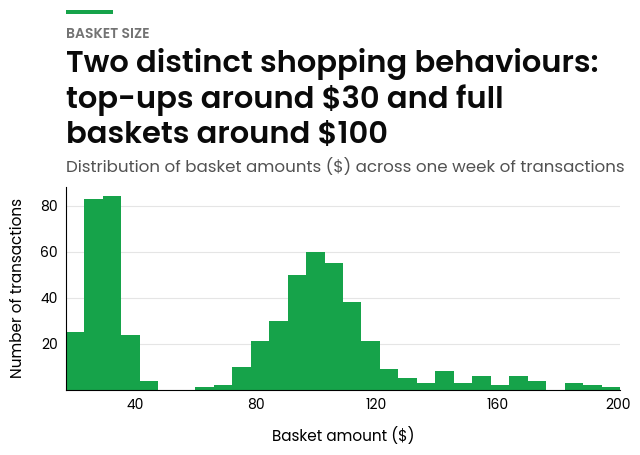

In [ ]:
histogram.plot(
    basket_data,
    value_col="basket_amount",
    bins=30,
    eyebrow="Basket size",
    title="Two distinct shopping behaviours: top-ups around \\$30 and full baskets around \\$100",
    subtitle="Distribution of basket amounts (\\$) across one week of transactions",
    x_label="Basket amount (\\$)",
    y_label="Number of transactions",
)
plt.show()

## Compare Distributions with `group_col`

Pass `group_col` alongside a single `value_col` to overlay one histogram per group, each in its own colour with translucency so smaller groups stay visible behind larger ones. Use this shape when the data is in long format (one row per observation, with a category column).

---

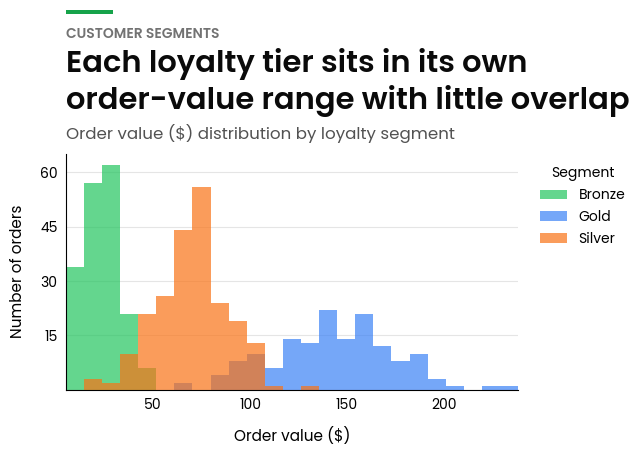

In [ ]:
histogram.plot(
    segment_orders,
    value_col="order_value",
    group_col="segment",
    bins=25,
    eyebrow="Customer segments",
    title="Each loyalty tier sits in its own order-value range with little overlap",
    subtitle="Order value (\\$) distribution by loyalty segment",
    x_label="Order value (\\$)",
    y_label="Number of orders",
    legend_title="Segment",
    move_legend_outside=True,
)
plt.show()

## Multiple Value Columns

If the data is already in wide format (one column per series), pass a list to `value_col` instead of using `group_col`. The two are mutually exclusive: passing both raises `ValueError` because the function wouldn't know how to disambiguate.

---

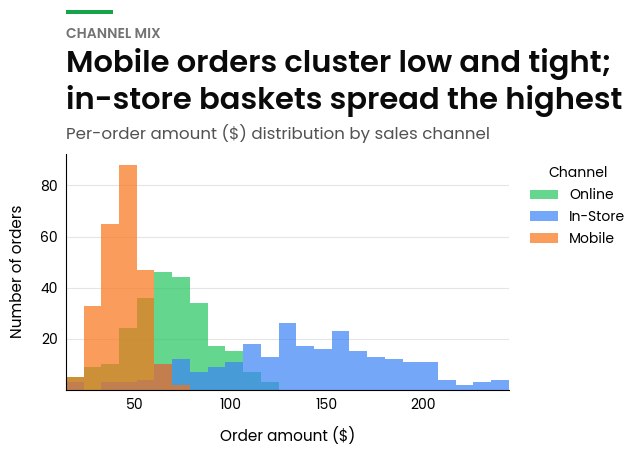

In [ ]:
histogram.plot(
    channel_orders,
    value_col=["Online", "In-Store", "Mobile"],
    bins=25,
    eyebrow="Channel mix",
    title="Mobile orders cluster low and tight; in-store baskets spread the highest",
    subtitle="Per-order amount (\\$) distribution by sales channel",
    x_label="Order amount (\\$)",
    y_label="Number of orders",
    legend_title="Channel",
    move_legend_outside=True,
)
plt.show()

## Outlier-Preserving Clipping with `clip_range`

Pass `clip_range=(lower, upper)` to clamp out-of-range values to the nearest boundary so they pile up at the edge bins instead of being dropped. Use it when you want the central mass to read clearly but still want to see how much sits beyond the window. Pass `None` on either side for one-sided clipping (e.g. `clip_range=(0, None)` to clamp only negatives). To drop outliers entirely instead, pass matplotlib's native `range=(lower, upper)` through `**kwargs`; specifying both raises `ValueError`.

---

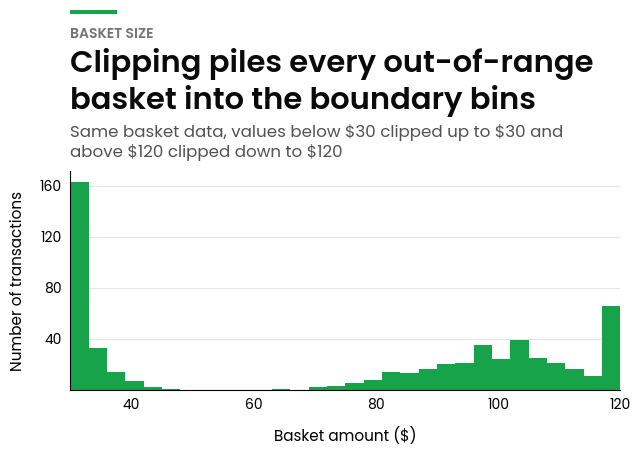

In [ ]:
histogram.plot(
    basket_data,
    value_col="basket_amount",
    clip_range=(30, 120),
    bins=30,
    eyebrow="Basket size",
    title="Clipping piles every out-of-range basket into the boundary bins",
    subtitle="Same basket data, values below \\$30 clipped up to \\$30 and above \\$120 clipped down to \\$120",
    x_label="Basket amount (\\$)",
    y_label="Number of transactions",
)
plt.show()

## Hatched Bars and Source Attribution

Pass `use_hatch=True` to overlay a different hatch pattern on each series. Helpful for accessibility (colour-impaired readers) and for charts destined for black-and-white print where the colour distinctions disappear. Combine with `source_text` for an attribution line on export-ready images.

---

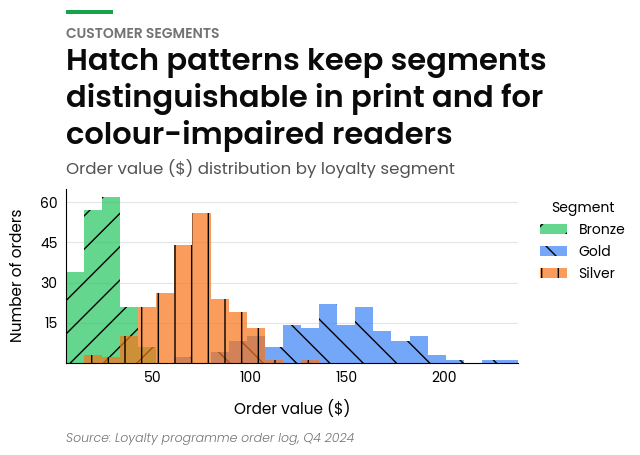

In [ ]:
histogram.plot(
    segment_orders,
    value_col="order_value",
    group_col="segment",
    bins=25,
    use_hatch=True,
    eyebrow="Customer segments",
    title="Hatch patterns keep segments distinguishable in print and for colour-impaired readers",
    subtitle="Order value (\\$) distribution by loyalty segment",
    x_label="Order value (\\$)",
    y_label="Number of orders",
    legend_title="Segment",
    move_legend_outside=True,
    source_text="Source: Loyalty programme order log, Q4 2024",
)
plt.show()